In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to [-1,1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


In [ ]:
BATCH_SIZE = 256

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE)

In [ ]:
def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*128, input_shape=(100,)))
    model.add(layers.Reshape((7,7,128)))

    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 7x7 --> 14x14
    model.add(layers.Conv2DTranspose(
        64,
        kernel_size=4,
        strides=2,
        padding="same"
    ))

    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())


    # 14x14 --> 28x28
    model.add(layers.Conv2DTranspose(
        1,
        kernel_size=4,
        strides=2,
        padding="same",
        activation="tanh"
    ))

    return model


generator = build_generator()

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 766,401 (2.92 MB)

 Trainable params: 766,017 (2.92 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
def build_discriminator():

    model = tf.keras.Sequential()

    model.add(layers.Conv2D(
        64,
        kernel_size=4,
        strides=2,
        padding="same",
        input_shape=(28,28,1)
    ))

    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))


    model.add(layers.Conv2D(
        128,
        kernel_size=4,
        strides=2,
        padding="same"
    ))

    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))


    model.add(layers.Flatten())

    model.add(layers.Dense(1, activation="sigmoid"))


    return model


discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

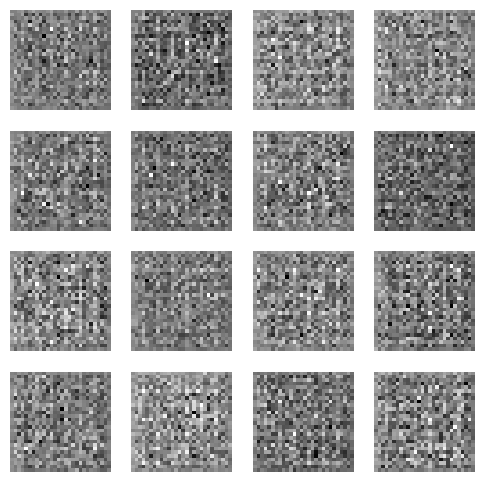

In [ ]:
noise = tf.random.normal([16,100])

fake_images = generator(noise)


plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(fake_images[i,:,:,0], cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()


g_optimizer = tf.keras.optimizers.Adam(
    0.0002,
    beta_1=0.5
)


d_optimizer = tf.keras.optimizers.Adam(
    0.0002,
    beta_1=0.5
)

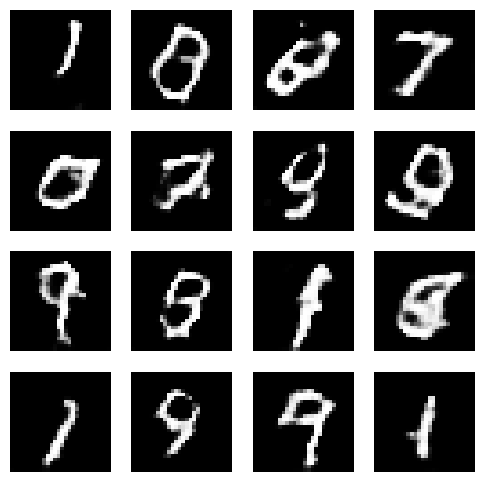

In [ ]:
noise = tf.random.normal([16,100])

generated_images = generator(noise)


plt.figure(figsize=(6,6))


for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated_images[i,:,:,0]*127.5+127.5,
        cmap="gray"
    )

    plt.axis("off")


plt.show()